# Plotting IWP with Centred Hurricane Visualizations

In [1]:
#%matplotlib inline

import os, sys, glob
import pylab as plt
import numpy as np
import scipy.ndimage

import seaborn as sns
sns.set_context('talk')

import datetime
import xarray as xr
xr.set_options(keep_attrs=True)

from matplotlib.patches import Rectangle, Circle

In [2]:
sys.path.append('../tools')
import timetools


## Arguments 

In [3]:
if 'launcher' in sys.argv[0]:
    idom = 1
    time_str = '20200910_1200'
else:
    idom = int( sys.argv[1] )
    time_str = sys.argv[2]

time = datetime.datetime.strptime(time_str, '%Y%m%d_%H%M')
dom = 'DOM' + str(idom).zfill(2)


In [4]:
if idom == 1: 
    res = 1200
    circle_width = 500
elif idom == 2:
    res = 600
    circle_width = 350    
elif idom == 3:
    res = 300
    circle_width = 200

In [5]:
nplots = 8
dt = 2 # in hours

tindex = np.arange(nplots)
times = time + tindex * datetime.timedelta( hours = dt )

In [6]:
times

array([datetime.datetime(2020, 9, 10, 12, 0),
       datetime.datetime(2020, 9, 10, 14, 0),
       datetime.datetime(2020, 9, 10, 16, 0),
       datetime.datetime(2020, 9, 10, 18, 0),
       datetime.datetime(2020, 9, 10, 20, 0),
       datetime.datetime(2020, 9, 10, 22, 0),
       datetime.datetime(2020, 9, 11, 0, 0),
       datetime.datetime(2020, 9, 11, 2, 0)], dtype=object)

## Open ICON Data

### Time Coordinate

In [7]:
def reset_timecoord( dset ):
    t = timetools.convert_timevec( dset.time.data )
    return dset.assign_coords({'time':t})



### ICON LEM 

In [8]:

def input_LEM( idom, time, mode = 'surface'):
    
    #data_path = f'/work/bb1376/data/icon/atlantic-cases/paulette/ifces2-atlanLEM-segment{iseg}-202009??-exp105/POSTPROC'
    #exp_path = '/work/bb1376/user/fabian/model/icon/icon-builds/icon-release-2025.04-2_intel-noopenmp/experiments/'
    exp_path = '/work/bb1376/data/icon/atlantic-cases/paulette/'
    data_path = f'{exp_path}/hurricane-centric_paulette2020-width200km_reinit12h-segment??-202009??T??00Z-exp111/POSTPROC/'


    
    dom = 'DOM' + str(idom).zfill(2)
    date_string = time.strftime('%Y%m%d') # '20200910T0??000Z'

    print(f'{data_path}/2d_{mode}_{dom}*{date_string}*regrid?km.nc')
    icon_regrid_files =  sorted( glob.glob( f'{data_path}/2d_{mode}_{dom}*{date_string}*regrid?km.nc') )

    for fname in icon_regrid_files:
        irg = xr.open_dataset( fname, )
        irg = reset_timecoord( irg )

        try:
            irg = irg.sel(time=time)
            try:
                irg = irg.isel(time=0)
            except:
                pass
                
            return irg.expand_dims({'dom':[dom,]})
        except:
#            print('time not found')
            continue

    return xr.zeros_like( irg.isel(time = 0) )



In [9]:
def custom_path_units( d ):
    d['tqv_dia'].attrs['units'] = 'mm'
    
    d['tqc_dia'] = 1e3 * d['tqc_dia']
    d['tqc_dia'].attrs['units'] = r'g m${}^{-3}$'
    
    d['tqi_dia'] = 1e3 * d['tqi_dia']
    d['tqi_dia'].attrs['units'] = r'g m${}^{-3}$'


In [10]:
def masking( d ):

    return d.where( d['tqv_dia'] > 0 )

In [11]:
d = []
for i in tindex:
    cloud = input_LEM(idom, times[i], mode = 'cloud')
    custom_path_units( cloud )
    cloud = masking( cloud )
    
    d += [cloud,]



/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width200km_reinit12h-segment??-202009??T??00Z-exp111/POSTPROC//2d_cloud_DOM01*20200910*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width200km_reinit12h-segment??-202009??T??00Z-exp111/POSTPROC//2d_cloud_DOM01*20200910*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width200km_reinit12h-segment??-202009??T??00Z-exp111/POSTPROC//2d_cloud_DOM01*20200910*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width200km_reinit12h-segment??-202009??T??00Z-exp111/POSTPROC//2d_cloud_DOM01*20200910*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width200km_reinit12h-segment??-202009??T??00Z-exp111/POSTPROC//2d_cloud_DOM01*20200910*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width200km_reinit12h-segme

### Open Best Fitting Track 

In [12]:
track_dir = '/work/bb1376/data/icon/atlantic-cases/derived-data/tracks/'

trackfile = f'{track_dir}/ifces2-atlanXL-20200907-exp021-DOM02_paulette_best-fit.nc'


In [13]:
track = xr.open_dataset( trackfile ).swap_dims({'index':'time'})

In [14]:
track = track[['longitude', 'latitude']].rolling( time=13, center=True).mean()

## Distance to the Track

In [15]:
def lonlat2xyz(lam, phi):
    cosphi = np.cos(phi)
    a_E = 6.371e3  # in kilometer
    return a_E *cosphi * np.cos(lam), a_E * cosphi * np.sin(lam), a_E * np.sin(phi)

In [16]:
def make_circular_mask( d ):
    
    track_center = track.sel(time = d.time, method = 'nearest')
    
    tlam, tphi = np.deg2rad( track_center.longitude.data), np.deg2rad( track_center.latitude.data)
    
    txyz = lonlat2xyz( tlam, tphi)
    
    glam, gphi = np.deg2rad( d.lon), np.deg2rad(d.lat)
    
    gxyz = lonlat2xyz( glam, gphi) 
    
    distance = np.sqrt( (txyz[0] - gxyz[0])**2  + (txyz[1] - gxyz[1])**2 + (txyz[2] - gxyz[2])**2)
    
    dmask = (distance<circle_width)

    return dmask


## Plotting

In [17]:
def plotter( d, vname, title, **add_kws):

    dmask = make_circular_mask( d )
    
    d[vname].plot( alpha = 0.2, add_colorbar = False, **add_kws)
    circplot = d[vname].where(dmask).plot( add_colorbar = False, **add_kws)
    sns.despine()
    plt.xlabel('longitude / deg E')
    plt.ylabel('latitude / deg N')
    plt.axis('off')    

    # centering
    dx = 6.
    dy = 6.
    
    x1, x2 = d.lon.where(dmask).min() - dx/2, d.lon.where(dmask).max() + dx/2
    y1, y2 = d.lat.where(dmask).min() - dy/2, d.lat.where(dmask).max() + dy/2

    plt.xlim(x1, x2)
    plt.ylim(y1, y2)

    ax = plt.gca()
    rect = ax.get_position()
    left, bottom, width, height = rect.bounds
    ax.set_position( [left, bottom, width, height] )
    y = bottom + height
    if y < 0.7:
        y = 0.1
    title = ax.set_title(title, fontsize = 18, y = y, )
    title.set_backgroundcolor((1, 1, 1, 0.5))  # RGBA format
    return circplot

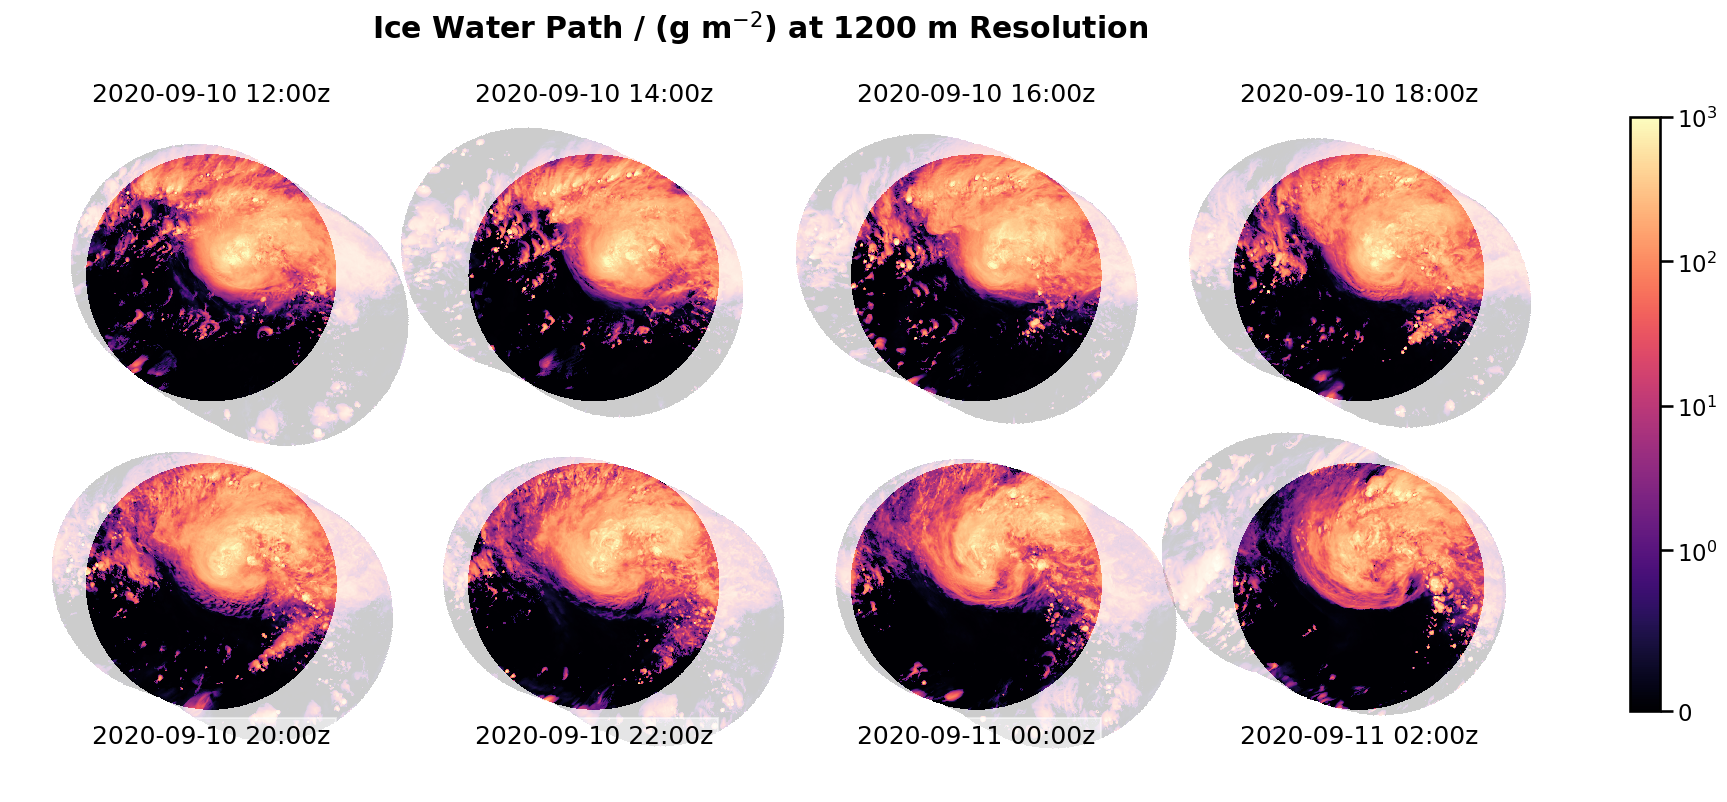

In [18]:
fig, axs = plt.subplots(ncols = nplots // 2, nrows = 2, figsize = (20,9))
plt.subplots_adjust( wspace = -0.05, hspace = -0.25, top = 0.91)
axs = axs.flatten()

title = r'Ice Water Path / (g m$^{-2}$)'
vname = 'tqi_dia'
mima = dict( vmin = 0, vmax = 1e3)
add_kws = dict( norm = plt.matplotlib.colors.SymLogNorm( linthresh = 1, **mima), 
              cmap = plt.cm.magma, **mima)
    
for i in range(nplots):

    plt.sca(axs[i])
    img = plotter( d[i],vname, times[i].strftime('%Y-%m-%d %H:%Mz'), **add_kws)

aex = fig.add_axes([0.85,0.2,0.1,0.66])
fig.colorbar(img, ax=aex, orientation='vertical', )
fig.delaxes(aex)


plt.suptitle(f'{title} at {res} m Resolution', fontweight = 'bold')

plt.savefig(f'../pics/lagrangian_circle_plot_iwp_dom{idom}.png', dpi = 150)

In [19]:
from matplotlib.colors import LinearSegmentedColormap

# Define the color stops with increasing brightness
colors = [
    (0.0, 0.0, 0.0),    # Black
    (0.1, 0.0, 0.1),    # Black
    (0.3, 0.0, 0.3),    # Dark Purple
    (0.5, 0.2, 0.5),    # Medium Purple
    (0.4, 0.4, 0.8),    # Light Blueish Purple
    (0.1, 0.6, 0.9),    # Modern Blue
    (0.6, 0.9, 1.0),    # Light Blue
    (0.95, 1.0, 1.0)     # Light Cyan
]
0# Create the custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom_magma_smooth", colors)


Text(0.5, 0.98, 'Ice Water Path / (g m$^{-2}$) at 1200 m Resolution')

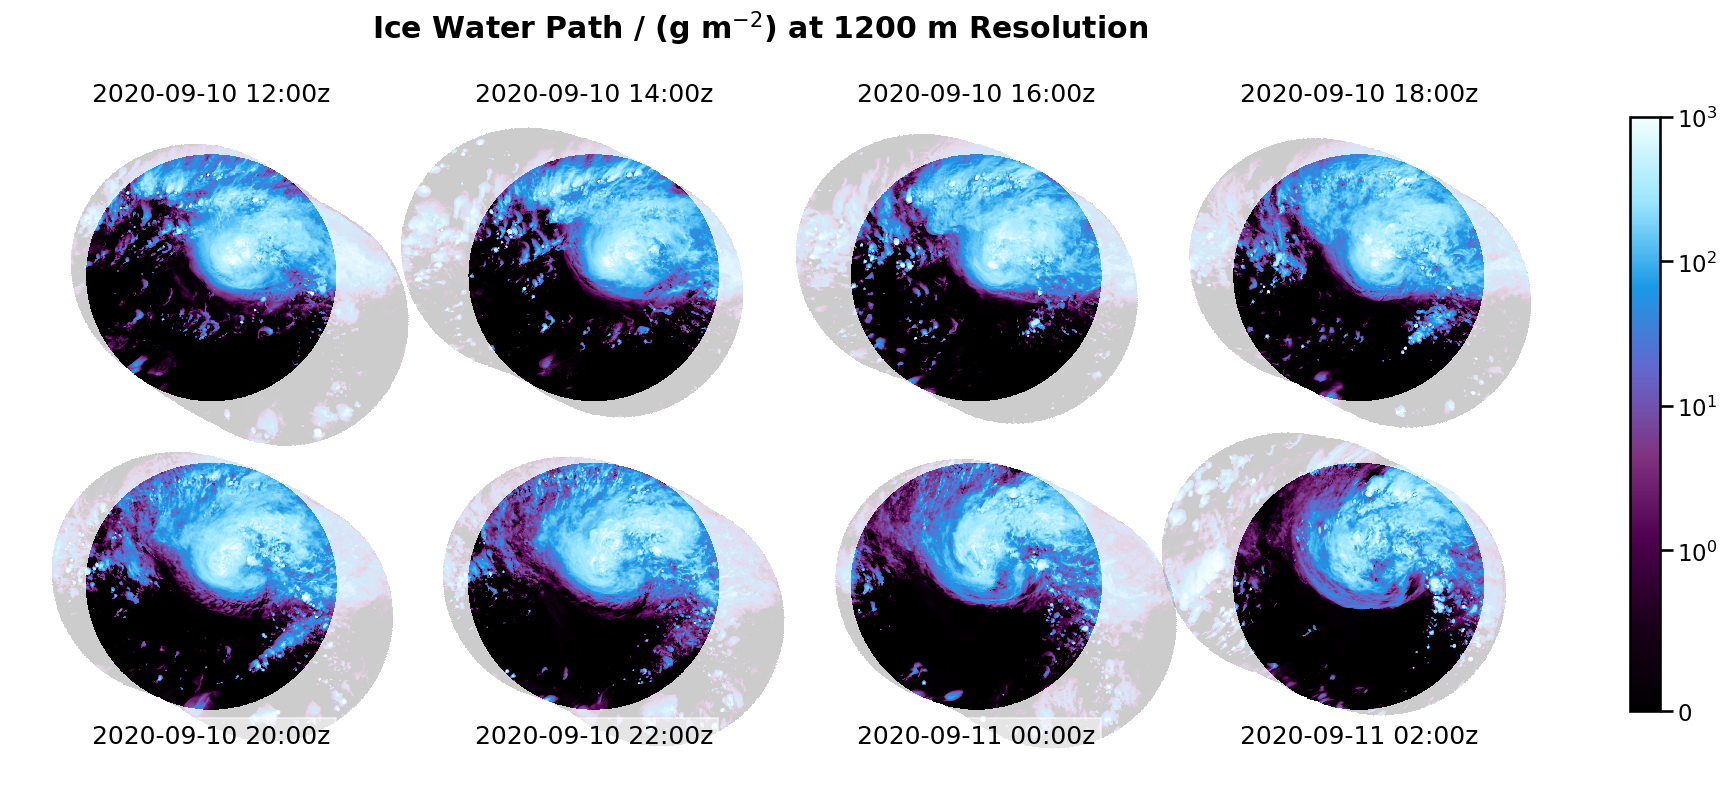

In [20]:
fig, axs = plt.subplots(ncols = nplots // 2, nrows = 2, figsize = (20,9))
plt.subplots_adjust( wspace = -0.05, hspace = -0.25, top = 0.91)
axs = axs.flatten()

title = r'Ice Water Path / (g m$^{-2}$)'
vname = 'tqi_dia'
mima = dict( vmin = 0, vmax = 1e3)
add_kws = dict( norm = plt.matplotlib.colors.SymLogNorm( linthresh = 1, **mima), 
              cmap = custom_cmap, **mima)
    
for i in range(nplots):

    plt.sca(axs[i])
    img = plotter( d[i],vname, times[i].strftime('%Y-%m-%d %H:%Mz'), **add_kws)

aex = fig.add_axes([0.85,0.2,0.1,0.66])
fig.colorbar(img, ax=aex, orientation='vertical', )
fig.delaxes(aex)


plt.suptitle(f'{title} at {res} m Resolution', fontweight = 'bold')


Text(0.5, 0.98, 'Ice Water Path / (g m$^{-2}$) at 1200 m Resolution')

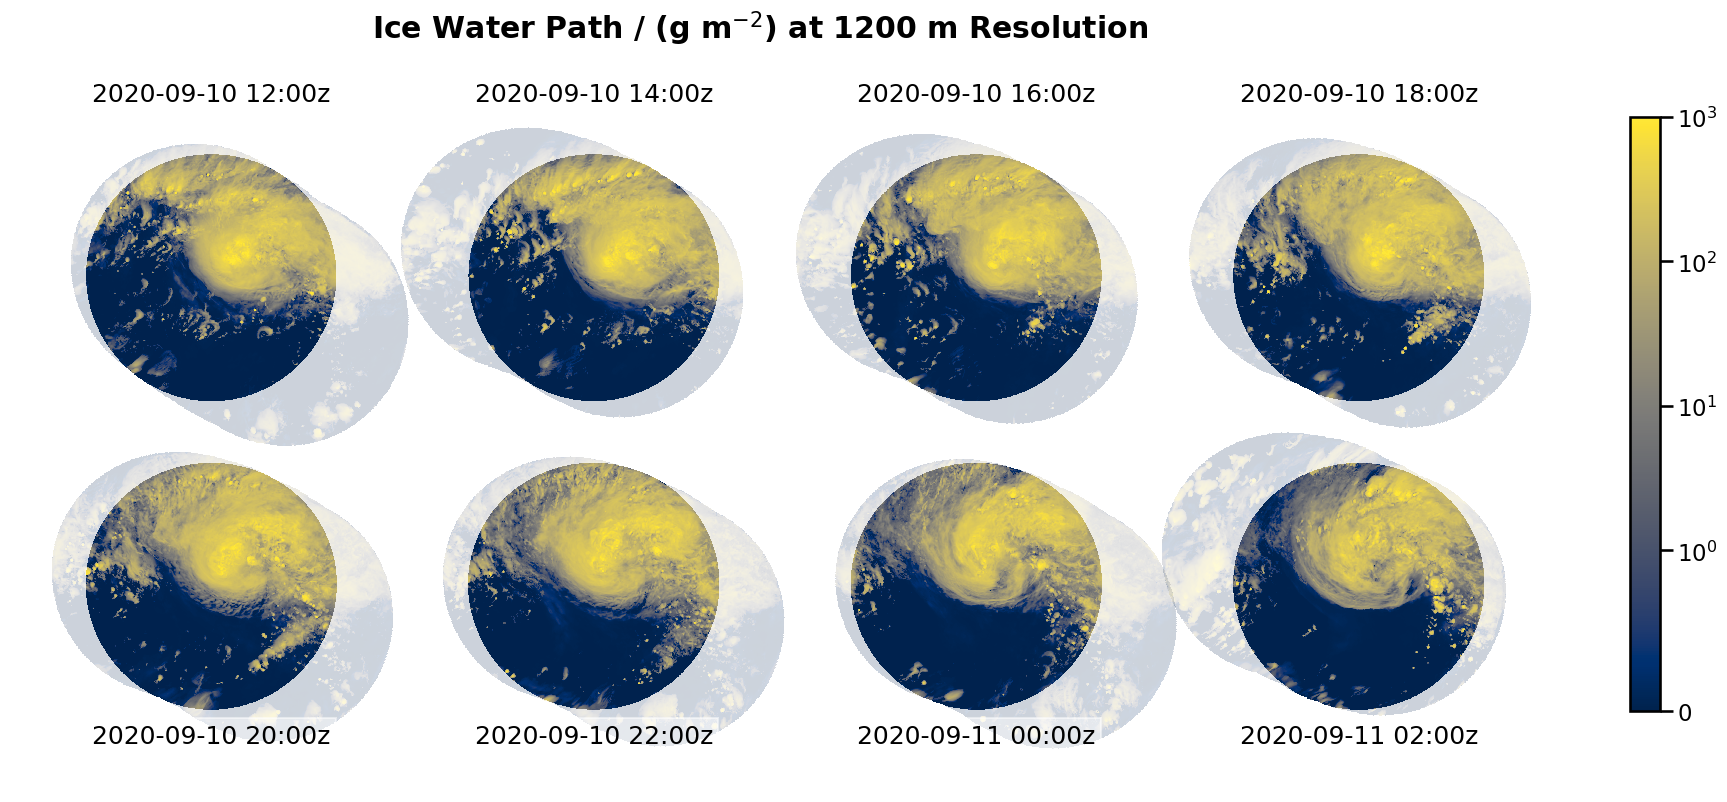

In [21]:
fig, axs = plt.subplots(ncols = nplots // 2, nrows = 2, figsize = (20,9))
plt.subplots_adjust( wspace = -0.05, hspace = -0.25, top = 0.91)
axs = axs.flatten()

title = r'Ice Water Path / (g m$^{-2}$)'
vname = 'tqi_dia'
mima = dict( vmin = 0, vmax = 1e3)
add_kws = dict( norm = plt.matplotlib.colors.SymLogNorm( linthresh = 1, **mima), 
              cmap = plt.cm.cividis, **mima)
    
for i in range(nplots):

    plt.sca(axs[i])
    img = plotter( d[i],vname, times[i].strftime('%Y-%m-%d %H:%Mz'), **add_kws)

aex = fig.add_axes([0.85,0.2,0.1,0.66])
fig.colorbar(img, ax=aex, orientation='vertical', )
fig.delaxes(aex)


plt.suptitle(f'{title} at {res} m Resolution', fontweight = 'bold')
